训练完毕，决策树模型已训练。


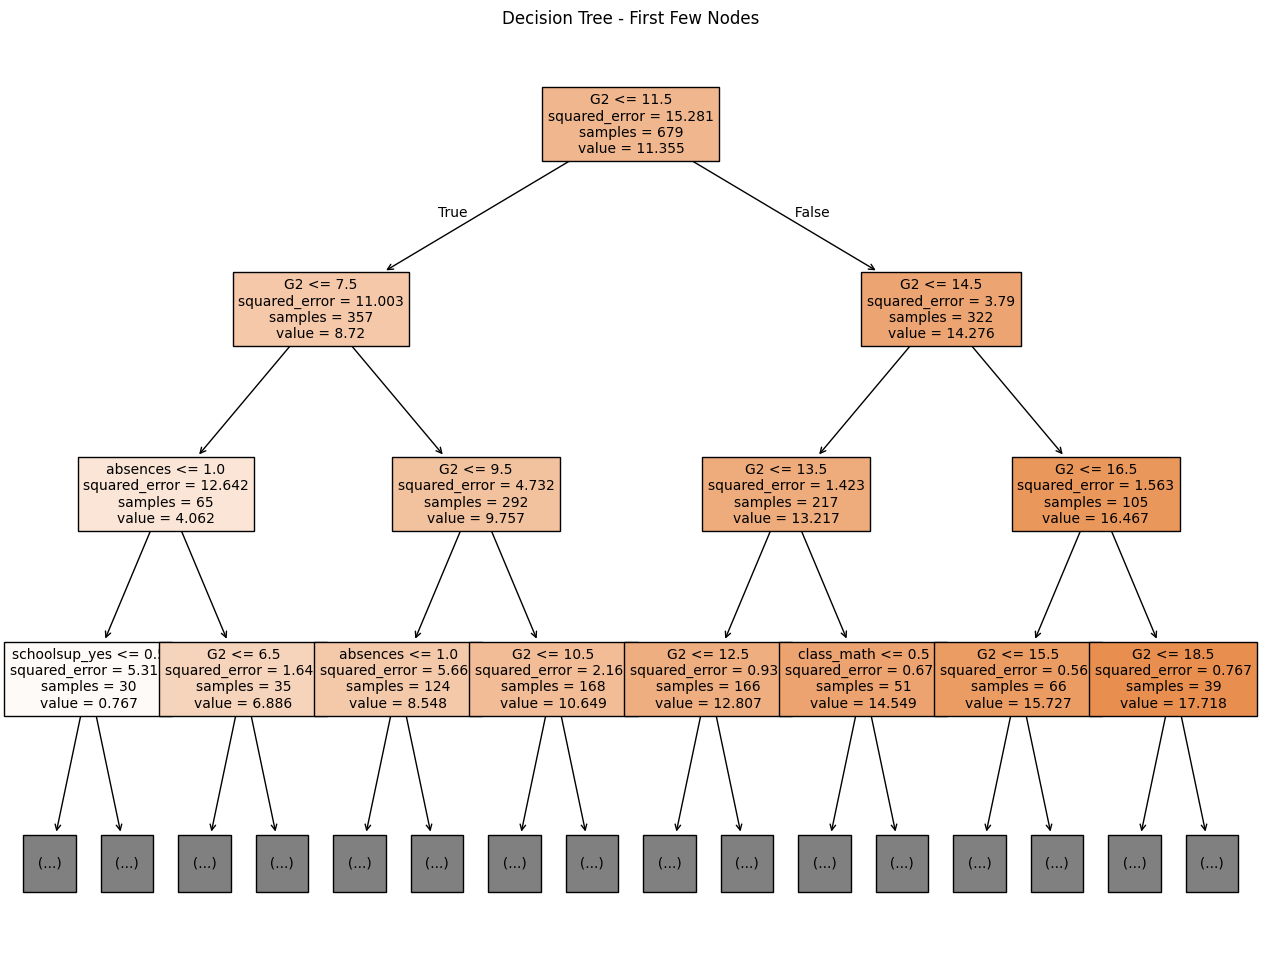

训练集数据已保存为 student_tree_train_data.csv，决策树模型已保存为 tree_model_2.pkl。


In [4]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
import joblib
import os
import matplotlib.pyplot as plt

# 读取清理后的数据
df = pd.read_csv("data/student_combined_cleaned.csv")

# 特征和目标
X = df.drop(columns=['G3']) # 选择所有列作为特征，去除目标变量 G3
y = df['G3'] # 将 G3 作为目标变量

# 对分类特征进行独热编码
X = pd.get_dummies(X)

# 划分训练集：70%用于训练
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.3, random_state=42)

# 合并训练集数据并保存
train_data = pd.concat([X_train, y_train], axis=1)
train_data.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_tree_train_data.csv", index=False)

# 训练决策树回归模型
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# 输出模型的权重
print("训练完毕，决策树模型已训练。")

# 确保模型保存的目录存在
if not os.path.exists('models'):
    os.makedirs('models')

# 绘制决策树的前几个节点
plt.figure(figsize=(16, 12))  # 增加图形大小
plot_tree(tree_model, feature_names=X.columns, filled=True, max_depth=3, fontsize=10)  # 调整字体大小
plt.title("Decision Tree - First Few Nodes")
plt.show()

# 保存训练好的决策树模型
joblib.dump(tree_model, "E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/tree_model_2.pkl")

print("训练集数据已保存为 student_tree_train_data.csv，决策树模型已保存为 tree_model_2.pkl。")

评估集的MSE: 6.164383561643835
评估集的R²: 0.5890292066058707


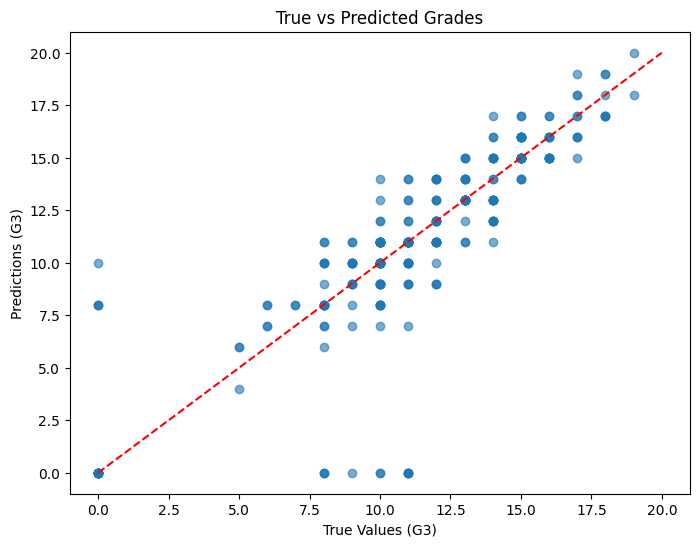

评估集数据已保存为 student_tree_eval_data.csv。


In [5]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 加载训练好的决策树模型
model = joblib.load("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/tree_model_2.pkl")

# 读取清理后的数据
df = pd.read_csv("data/student_combined_cleaned.csv")

# 特征和目标
X = df.drop(columns=['G3'])
y = df['G3']

# 对分类特征进行独热编码
X = pd.get_dummies(X)

# 划分评估集：30%用于评估
_, X_eval, _, y_eval = train_test_split(X, y, test_size=0.3, random_state=42)

# 合并评估集数据并保存
eval_data = pd.concat([X_eval, y_eval], axis=1)
eval_data.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_tree_eval_data.csv", index=False)

# 使评估集特征与训练集一致
X_eval = X_eval.reindex(columns=model.feature_names_in_, fill_value=0)

# 预测评估集
y_pred = model.predict(X_eval)

# 评估模型
mse = mean_squared_error(y_eval, y_pred)
r2 = r2_score(y_eval, y_pred)

# 打印评估结果
print("评估集的MSE:", mse)
print("评估集的R²:", r2)

# 可视化预测结果
plt.figure(figsize=(8, 6))
plt.scatter(y_eval, y_pred, alpha=0.6)
plt.plot([0, 20], [0, 20], color='red', linestyle='--')  # 绘制理想的完美拟合线
plt.xlabel("True Values (G3)")
plt.ylabel("Predictions (G3)")
plt.title("True vs Predicted Grades")
plt.show()

print("评估集数据已保存为 student_tree_eval_data.csv。")

=== 模型 A（无 G1, G2） ===
MSE: 18.794520547945204
R² : -0.2530042856372119

=== 模型 B（含 G1, G2） ===
MSE: 5.506849315068493
R² : 0.6328660912345778


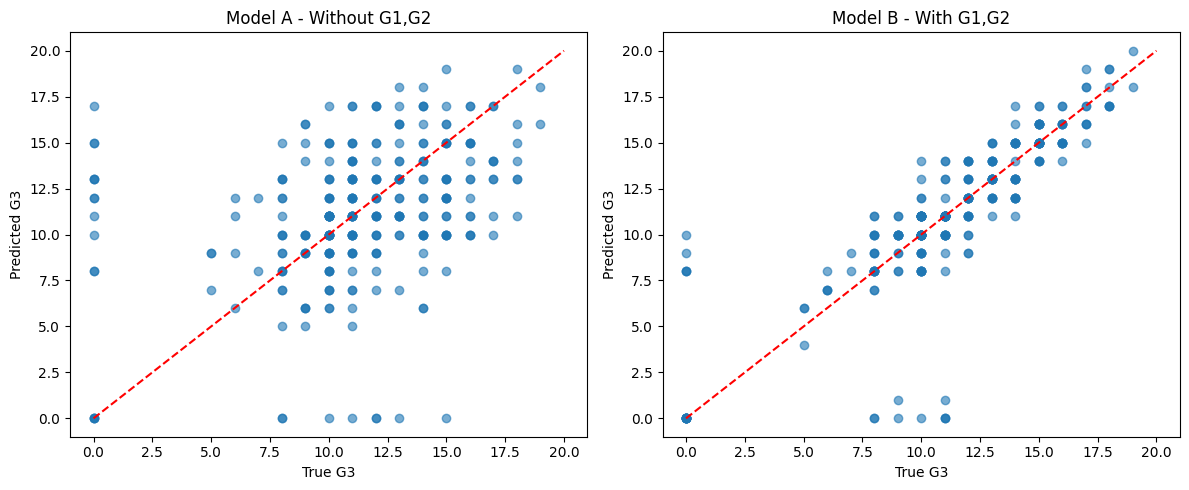

In [6]:
import pandas as pd
import joblib
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("data/student_combined_cleaned.csv")

# 分别构建两个版本的特征集
X_with_G1G2 = df.drop(columns=['G3'])                   # 保留 G1, G2
X_without_G1G2 = df.drop(columns=['G1', 'G2', 'G3'])    # 去除 G1, G2

# 目标变量
y = df['G3']

# 独热编码
X_with_G1G2 = pd.get_dummies(X_with_G1G2)
X_without_G1G2 = pd.get_dummies(X_without_G1G2)

# 保证列对齐（避免 dummy 编码造成列不一致）
X_with_G1G2, X_without_G1G2 = X_with_G1G2.align(X_without_G1G2, join='outer', fill_value=0)

# 相同评估划分
X_train_a, X_eval_a, y_train, y_eval = train_test_split(X_without_G1G2, y, test_size=0.3, random_state=42)
X_train_b, X_eval_b, _, _ = train_test_split(X_with_G1G2, y, test_size=0.3, random_state=42)

# 模型 A：不含 G1, G2
model_a = DecisionTreeRegressor(random_state=42)
model_a.fit(X_train_a, y_train)
y_pred_a = model_a.predict(X_eval_a)

# 模型 B：包含 G1, G2
model_b = DecisionTreeRegressor(random_state=42)
model_b.fit(X_train_b, y_train)
y_pred_b = model_b.predict(X_eval_b)

# 模型评估
print("=== 模型 A（无 G1, G2） ===")
print("MSE:", mean_squared_error(y_eval, y_pred_a))
print("R² :", r2_score(y_eval, y_pred_a))

print("\n=== 模型 B（含 G1, G2） ===")
print("MSE:", mean_squared_error(y_eval, y_pred_b))
print("R² :", r2_score(y_eval, y_pred_b))

# 可视化对比预测效果
plt.figure(figsize=(12, 5))

# A 模型散点图
plt.subplot(1, 2, 1)
plt.scatter(y_eval, y_pred_a, alpha=0.6)
plt.plot([0, 20], [0, 20], 'r--')
plt.title("Model A - Without G1,G2")
plt.xlabel("True G3")
plt.ylabel("Predicted G3")

# B 模型散点图
plt.subplot(1, 2, 2)
plt.scatter(y_eval, y_pred_b, alpha=0.6)
plt.plot([0, 20], [0, 20], 'r--')
plt.title("Model B - With G1,G2")
plt.xlabel("True G3")
plt.ylabel("Predicted G3")

plt.tight_layout()
plt.show()

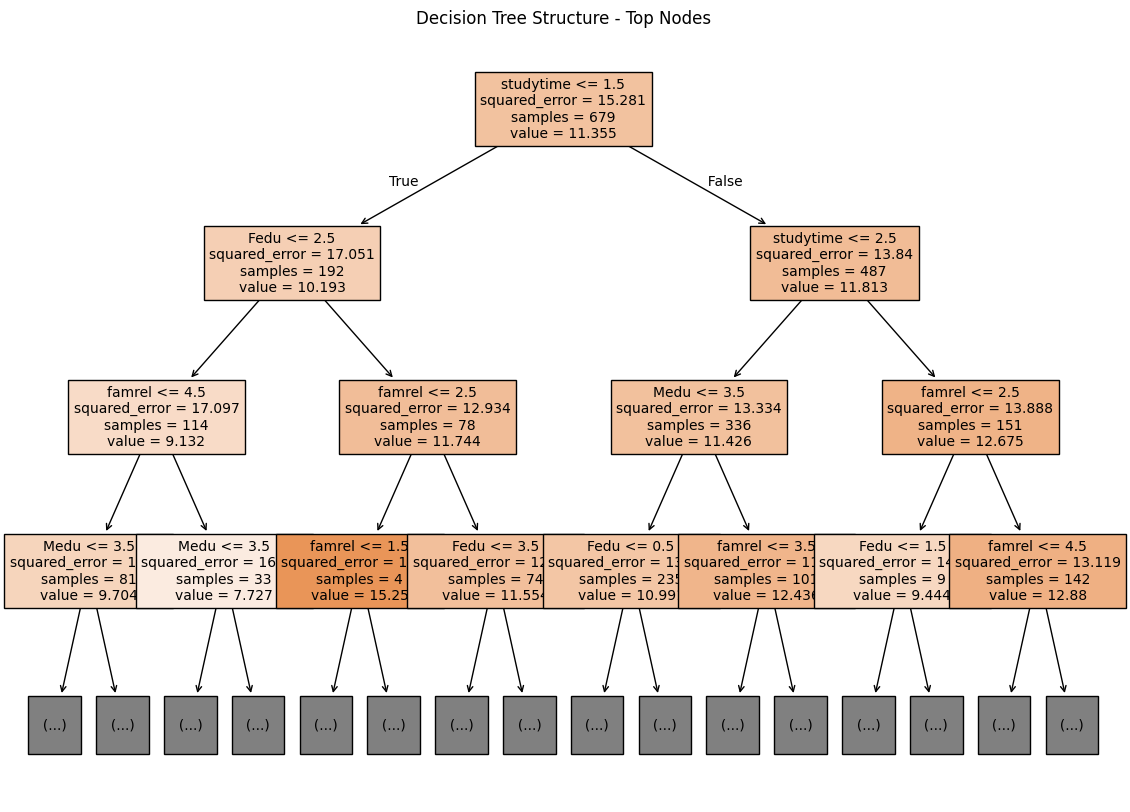


特征重要性：
studytime    0.360492
Fedu         0.294028
famrel       0.211366
Medu         0.134113
dtype: float64

训练集数据已保存为 E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_tree_train_selected.csv
模型已保存为 E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/tree_model_selected.pkl
决策树结构图已保存为 E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/tree_structure_selected.png


In [7]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
import joblib
import os
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("data/student_combined_cleaned.csv")

# 选取特征和目标变量
features = ['Medu', 'Fedu', 'studytime', 'famrel']
target = 'G3'
selected_data = df[features + [target]]

# 保存完整特征数据
selected_data.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_tree_selected_data.csv", index=False)

# 划分训练数据
X = selected_data[features]
y = selected_data[target]
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.3, random_state=42)

# 保存训练数据
train_data = pd.concat([X_train, y_train], axis=1)
train_data.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_tree_train_selected.csv", index=False)

# 训练决策树模型
model = DecisionTreeRegressor(random_state=42, max_depth=4)
model.fit(X_train, y_train)

# 保存模型
joblib.dump(model, "E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/tree_model_selected.pkl")

# 可视化前几层决策树
plt.figure(figsize=(14, 10))
plot_tree(model, feature_names=features, filled=True, max_depth=3, fontsize=10)
plt.title("Decision Tree Structure - Top Nodes")
plt.savefig("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/tree_structure_selected.png")
plt.show()

# 输出特征重要性
importances = pd.Series(model.feature_importances_, index=features)
print("\n特征重要性：")
print(importances.sort_values(ascending=False))

print("\n训练集数据已保存为 E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_tree_train_selected.csv")
print("模型已保存为 E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/tree_model_selected.pkl")
print("决策树结构图已保存为 E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/tree_structure_selected.png")

评估集结果：
MSE: 16.14344373917167
R² : -0.07626071857080774


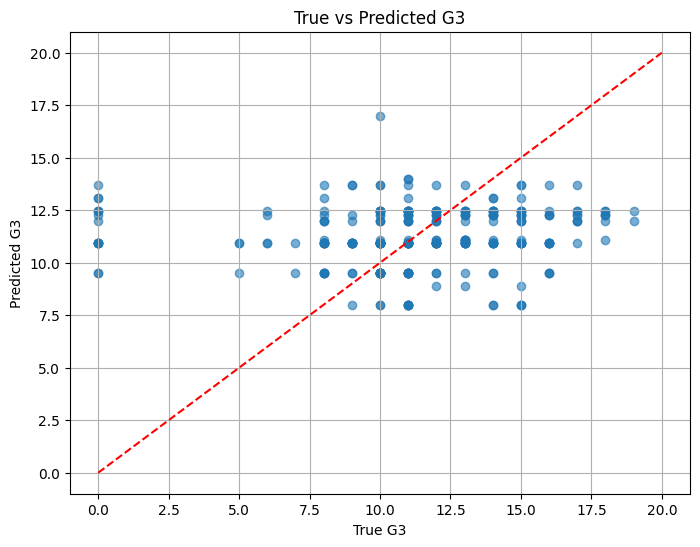

评估集数据已保存为 E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_tree_eval_selected.csv


In [8]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("data/student_combined_cleaned.csv")

# 特征与目标
features = ['Medu', 'Fedu', 'studytime', 'famrel']
target = 'G3'
selected_data = df[features + [target]]

# 划分评估数据
X = selected_data[features]
y = selected_data[target]
_, X_eval, _, y_eval = train_test_split(X, y, test_size=0.3, random_state=42)

# 保存评估数据
eval_data = pd.concat([X_eval, y_eval], axis=1)
eval_data.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_tree_eval_selected.csv", index=False)

# 加载模型
model = joblib.load("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/tree_model_selected.pkl")

# 预测并评估
y_pred = model.predict(X_eval)
mse = mean_squared_error(y_eval, y_pred)
r2 = r2_score(y_eval, y_pred)

# 打印评估结果
print("评估集结果：")
print("MSE:", mse)
print("R² :", r2)

# 可视化真实 vs 预测
plt.figure(figsize=(8, 6))
plt.scatter(y_eval, y_pred, alpha=0.6)
plt.plot([0, 20], [0, 20], 'r--')
plt.xlabel("True G3")
plt.ylabel("Predicted G3")
plt.title("True vs Predicted G3")
plt.grid(True)
plt.show()

print("评估集数据已保存为 E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_tree_eval_selected.csv")